## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── Paths ──────────────────────────────────────────────────────────────────────
RAW_DIR    = '/content/drive/MyDrive/insurance_fraud/raw/'       # Put your 8 CSVs here
OUTPUT_DIR = '/content/drive/MyDrive/insurance_fraud/processed/' # Processed files saved here

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('✅ Drive mounted.')
print('📂 Raw files expected at :', RAW_DIR)
print('📂 Outputs will be saved to:', OUTPUT_DIR)

# ── Verify all 8 files exist ───────────────────────────────────────────────────
REQUIRED_FILES = [
    'Train-1542865627584.csv',
    'Train_Beneficiarydata-1542865627584.csv',
    'Train_Inpatientdata-1542865627584.csv',
    'Train_Outpatientdata-1542865627584.csv',
    'Test-1542969243754.csv',
    'Test_Beneficiarydata-1542969243754.csv',
    'Test_Inpatientdata-1542969243754.csv',
    'Test_Outpatientdata-1542969243754.csv',
]

print('\n🔍 Checking files...')
all_found = True
for f in REQUIRED_FILES:
    path = RAW_DIR + f
    status = '✅' if os.path.exists(path) else '❌ MISSING'
    if '❌' in status:
        all_found = False
    print(f'  {status} {f}')

if all_found:
    print('\n🎉 All 8 files found! Ready to proceed.')
else:
    print('\n⚠️  Some files are missing. Check the filenames match exactly (they have timestamps).')
    print('    Tip: Run  !ls "/content/drive/MyDrive/insurance_fraud/raw/"  to see actual filenames.')

Mounted at /content/drive
✅ Drive mounted.
📂 Raw files expected at : /content/drive/MyDrive/insurance_fraud/raw/
📂 Outputs will be saved to: /content/drive/MyDrive/insurance_fraud/processed/

🔍 Checking files...
  ✅ Train-1542865627584.csv
  ✅ Train_Beneficiarydata-1542865627584.csv
  ✅ Train_Inpatientdata-1542865627584.csv
  ✅ Train_Outpatientdata-1542865627584.csv
  ✅ Test-1542969243754.csv
  ✅ Test_Beneficiarydata-1542969243754.csv
  ✅ Test_Inpatientdata-1542969243754.csv
  ✅ Test_Outpatientdata-1542969243754.csv

🎉 All 8 files found! Ready to proceed.


##  Install & Import Libraries

In [ ]:
# Install any missing packages
!pip install imbalanced-learn --quiet
!pip install pyarrow --quiet   # For saving .parquet files (faster than CSV)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import gc  # Garbage collector — important for Colab RAM management

from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0D1B3E',
    'axes.facecolor':   '#132447',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'axes.titlecolor':  'white',
    'axes.edgecolor':   '#1DB8C4',
    'grid.color':       '#1D3557',
    'font.family':      'DejaVu Sans',
})
ACCENT = '#1DB8C4'
RED    = '#E84C4C'
GREEN  = '#22C97A'

print('✅ Libraries imported successfully.')

✅ Libraries imported successfully.


## Cell 3 — Helper Functions

In [ ]:
def load_csv(filename, parse_dates=None, dtype_overrides=None):
    """
    Loads a CSV with memory optimization.
    - Converts object columns to 'category' dtype (saves ~40% RAM)
    - Parses date columns automatically
    """
    path = RAW_DIR + filename
    df = pd.read_csv(
        path,
        parse_dates=parse_dates or [],
        dtype=dtype_overrides or {},
        low_memory=False
    )
    # Convert all object columns to category to save memory
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype('category')
    print(f'  Loaded {filename}: {df.shape[0]:,} rows × {df.shape[1]} cols  |  RAM: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
    return df


def print_null_report(df, name):
    """Prints a clean missing value report for a DataFrame."""
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0].sort_values(ascending=False)
    if len(nulls) == 0:
        print(f'✅ {name}: No missing values.')
        return
    print(f'\n⚠️  {name} — Missing Values:')
    pct = (nulls / len(df) * 100).round(2)
    report = pd.DataFrame({'Missing Count': nulls, 'Missing %': pct})
    print(report.to_string())


def free_memory(*dfs):
    """Delete DataFrames and force garbage collection to free Colab RAM."""
    for df in dfs:
        del df
    gc.collect()
    print('🗑️  Memory freed.')


print('✅ Helper functions defined.')

✅ Helper functions defined.


In [ ]:
print('📥 Loading TRAIN files...')

# Labels: which providers are fraudulent
train_labels = load_csv('Train-1542865627584.csv')

# Patient demographics + chronic conditions
train_bene = load_csv(
    'Train_Beneficiarydata-1542865627584.csv',
    parse_dates=['DOB', 'DOD']
)

# Hospital (admitted) claims — loaded in chunks to save RAM
print('  Loading Inpatient data in chunks...')
chunks = []
for chunk in pd.read_csv(
    RAW_DIR + 'Train_Inpatientdata-1542865627584.csv',
    parse_dates=['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt'],
    chunksize=20000,
    low_memory=False
):
    chunks.append(chunk)
train_inp = pd.concat(chunks, ignore_index=True)
del chunks; gc.collect()
print(f'  Loaded Train_Inpatientdata: {train_inp.shape[0]:,} rows × {train_inp.shape[1]} cols')

# OPD (non-admitted) claims — largest file, chunk load critical
print('  Loading Outpatient data in chunks (517K rows — takes ~30 seconds)...')
chunks = []
for chunk in pd.read_csv(
    RAW_DIR + 'Train_Outpatientdata-1542865627584.csv',
    parse_dates=['ClaimStartDt', 'ClaimEndDt'],
    chunksize=50000,
    low_memory=False
):
    chunks.append(chunk)
train_out = pd.concat(chunks, ignore_index=True)
del chunks; gc.collect()
print(f'  Loaded Train_Outpatientdata: {train_out.shape[0]:,} rows × {train_out.shape[1]} cols')

print('\n📥 Loading TEST files...')
test_labels = load_csv('Test-1542969243754.csv')
test_bene   = load_csv('Test_Beneficiarydata-1542969243754.csv', parse_dates=['DOB', 'DOD'])

chunks = []
for chunk in pd.read_csv(RAW_DIR + 'Test_Inpatientdata-1542969243754.csv',
    parse_dates=['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt'],
    chunksize=20000, low_memory=False):
    chunks.append(chunk)
test_inp = pd.concat(chunks, ignore_index=True)
del chunks; gc.collect()
print(f'  Loaded Test_Inpatientdata: {test_inp.shape[0]:,} rows × {test_inp.shape[1]} cols')

chunks = []
for chunk in pd.read_csv(RAW_DIR + 'Test_Outpatientdata-1542969243754.csv',
    parse_dates=['ClaimStartDt', 'ClaimEndDt'],
    chunksize=50000, low_memory=False):
    chunks.append(chunk)
test_out = pd.concat(chunks, ignore_index=True)
del chunks; gc.collect()
print(f'  Loaded Test_Outpatientdata: {test_out.shape[0]:,} rows × {test_out.shape[1]} cols')

print('\n✅ All 8 files loaded successfully!')

📥 Loading TRAIN files...
  Loaded Train-1542865627584.csv: 5,410 rows × 2 cols  |  RAM: 0.5 MB
  Loaded Train_Beneficiarydata-1542865627584.csv: 138,556 rows × 25 cols  |  RAM: 38.5 MB
  Loading Inpatient data in chunks...
  Loaded Train_Inpatientdata: 40,474 rows × 30 cols
  Loading Outpatient data in chunks (517K rows — takes ~30 seconds)...
  Loaded Train_Outpatientdata: 517,737 rows × 27 cols

📥 Loading TEST files...
  Loaded Test-1542969243754.csv: 1,353 rows × 1 cols  |  RAM: 0.1 MB
  Loaded Test_Beneficiarydata-1542969243754.csv: 63,968 rows × 25 cols  |  RAM: 17.9 MB
  Loaded Test_Inpatientdata: 9,551 rows × 30 cols
  Loaded Test_Outpatientdata: 125,841 rows × 27 cols

✅ All 8 files loaded successfully!


In [ ]:
# ── DIAGNOSTIC: Print all column names for every loaded file ──
for name, df in [('train_labels', train_labels), ('train_bene', train_bene),
                  ('train_inp', train_inp), ('train_out', train_out)]:
    print(f"\n{name}: {df.columns.tolist()}")


train_labels: ['Provider', 'PotentialFraud', 'fraud_label']

train_bene: ['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']

train_inp: ['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode

## Cell 5 — Quick Schema Inspection

In [ ]:
# Preview each file briefly so you know what you're working with
datasets = {
    'train_labels': train_labels,
    'train_bene':   train_bene,
    'train_inp':    train_inp,
    'train_out':    train_out,
}

for name, df in datasets.items():
    print(f'\n{'='*60}')
    print(f'📋 {name}  |  Shape: {df.shape}')
    print(f'   Columns: {list(df.columns)}')
    print(f'   Dtypes:\n{df.dtypes.value_counts().to_string()}')

print('\n\n📌 KEY JOIN COLUMNS:')
print('  BeneID   — links Beneficiary ↔ Inpatient ↔ Outpatient')
print('  Provider — links all claims ↔ Fraud Labels')


📋 train_labels  |  Shape: (5410, 2)
   Columns: ['Provider', 'PotentialFraud']
   Dtypes:
category    1
category    1

📋 train_bene  |  Shape: (138556, 25)
   Columns: ['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']
   Dtypes:
int64             21
datetime64[ns]     2
category           1
category           1

📋 train_inp  |  Shape: (40474, 30)
   Columns: ['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician',

## Cell 6 — Null Value Reports (Before Cleaning)

In [ ]:
print_null_report(train_labels, 'train_labels')
print_null_report(train_bene,   'train_bene')
print_null_report(train_inp,    'train_inp')
print_null_report(train_out,    'train_out')

✅ train_labels: No missing values.

⚠️  train_bene — Missing Values:
     Missing Count  Missing %
DOD         137135      98.97

⚠️  train_inp — Missing Values:
                     Missing Count  Missing %
ClmProcedureCode_6           40474     100.00
ClmProcedureCode_5           40465      99.98
ClmProcedureCode_4           40358      99.71
ClmProcedureCode_3           39509      97.62
ClmDiagnosisCode_10          36547      90.30
OtherPhysician               35784      88.41
ClmProcedureCode_2           35020      86.52
ClmProcedureCode_1           17326      42.81
OperatingPhysician           16644      41.12
ClmDiagnosisCode_9           13497      33.35
ClmDiagnosisCode_8            9942      24.56
ClmDiagnosisCode_7            7258      17.93
ClmDiagnosisCode_6            4838      11.95
ClmDiagnosisCode_5            2894       7.15
ClmDiagnosisCode_4            1534       3.79
DeductibleAmtPaid              899       2.22
ClmDiagnosisCode_3             676       1.67
ClmDiagnos

## Cell 7 — Clean Beneficiary Data

In [ ]:
def clean_beneficiary(df):
    """
    Cleans the beneficiary (patient demographics) dataframe:
    - Converts DOB/DOD to datetime
    - Computes Age at time of data collection
    - Creates is_deceased flag
    - Fills missing chronic condition flags with 0 (not diagnosed)
    - Computes total_chronic_conditions score
    """
    df = df.copy()

    # Parse dates if not already parsed
    for col in ['DOB', 'DOD']:
        if df[col].dtype == 'object' or str(df[col].dtype) == 'category':
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # Reference date — last date in the dataset
    ref_date = pd.Timestamp('2009-12-01')

    # Age in years
    df['Age'] = ((ref_date - df['DOB']).dt.days / 365.25).round(1)
    df['Age'] = df['Age'].clip(0, 120)  # Remove outliers

    # is_deceased: 1 if DOD exists (patient died during observation period)
    df['is_deceased'] = df['DOD'].notna().astype(int)

    # Chronic condition columns: 1 = has condition, 2 = no condition
    # Remap to 1/0 and fill nulls with 0
    chronic_cols = [
        'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
        'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
        'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
        'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
        'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
        'ChronicCond_stroke'
    ]
    for col in chronic_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
            # In raw data: 1 = Yes, 2 = No → remap to 1/0
            df[col] = df[col].map({'1': 1, '2': 0}).fillna(0).astype(int)

    # Total number of chronic conditions per patient (fraud signal: more diagnoses = inflated billing)
    available_chronic = [c for c in chronic_cols if c in df.columns]
    df['total_chronic_conditions'] = df[available_chronic].sum(axis=1)

    # Gender: 1=Male, 2=Female → remap
    if 'Gender' in df.columns:
        df['Gender'] = df['Gender'].astype(str).map({'1': 0, '2': 1}).fillna(0).astype(int)

    # Race: fill missing
    if 'Race' in df.columns:
        df['Race'] = pd.to_numeric(df['Race'], errors='coerce').fillna(df['Race'].mode()[0])

    # Reimbursement columns: fill missing with 0
    reimb_cols = [c for c in df.columns if 'Reimbursement' in c or 'Deductible' in c]
    df[reimb_cols] = df[reimb_cols].fillna(0)

    # Drop raw date columns (we've extracted what we need)
    df.drop(columns=['DOB', 'DOD'], inplace=True, errors='ignore')

    return df


train_bene_clean = clean_beneficiary(train_bene)
test_bene_clean  = clean_beneficiary(test_bene)

print('✅ Beneficiary data cleaned.')
print(f'   Train bene shape: {train_bene_clean.shape}')
print(f'   Test  bene shape: {test_bene_clean.shape}')
print(f'\n   New columns added: Age, is_deceased, total_chronic_conditions')
train_bene_clean[['Age', 'is_deceased', 'total_chronic_conditions']].describe()

✅ Beneficiary data cleaned.
   Train bene shape: (138556, 26)
   Test  bene shape: (63968, 26)

   New columns added: Age, is_deceased, total_chronic_conditions


,Age,is_deceased,total_chronic_conditions
count,138556.00,138556.00,138556.00
mean,73.59,0.01,3.74
std,12.73,0.10,2.35
min,26.00,0.00,0.00
25%,68.00,0.00,2.00
50%,74.30,0.00,4.00
75%,81.90,0.00,5.00
max,100.90,1.00,11.00


## Cell 8 — Clean Inpatient Data

In [ ]:
def clean_inpatient(df):
    """
    Cleans inpatient (hospital admission) claims:
    - Computes hospital_stay_days (fraud signal: inflated stays)
    - Fills missing physician codes with 'UNKNOWN'
    - Fills missing monetary amounts with 0
    - Fills missing diagnosis codes with 'MISSING'
    """
    df = df.copy()

    # Parse dates if not already
    for col in ['AdmissionDt', 'DischargeDt', 'ClaimStartDt', 'ClaimEndDt']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # Hospital stay duration in days (key fraud signal)
    if 'AdmissionDt' in df.columns and 'DischargeDt' in df.columns:
        df['hospital_stay_days'] = (df['DischargeDt'] - df['AdmissionDt']).dt.days
        df['hospital_stay_days'] = df['hospital_stay_days'].clip(0, 365).fillna(0)

    # Claim duration in days
    if 'ClaimStartDt' in df.columns and 'ClaimEndDt' in df.columns:
        df['claim_duration_days'] = (df['ClaimEndDt'] - df['ClaimStartDt']).dt.days
        df['claim_duration_days'] = df['claim_duration_days'].clip(0, 365).fillna(0)

    # Physician code columns: fill nulls with 'UNKNOWN'
    physician_cols = ['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician']
    for col in physician_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).replace('nan', 'UNKNOWN').fillna('UNKNOWN')

    # Diagnosis & procedure code columns: fill with 'MISSING'
    diag_cols = [c for c in df.columns if 'ClmDiagnosisCode' in c or 'ClmProcedureCode' in c]
    for col in diag_cols:
        df[col] = df[col].astype(str).replace('nan', 'MISSING').fillna('MISSING')

    # Monetary columns: fill with 0
    money_cols = [c for c in df.columns if any(k in c for k in ['Amt', 'Reimbursement', 'Deductible'])]
    df[money_cols] = df[money_cols].fillna(0)

    # Drop raw date columns (keep only derived duration features)
    df.drop(columns=['AdmissionDt', 'DischargeDt', 'ClaimStartDt', 'ClaimEndDt'],
            inplace=True, errors='ignore')

    return df


train_inp_clean = clean_inpatient(train_inp)
test_inp_clean  = clean_inpatient(test_inp)

print('✅ Inpatient data cleaned.')
print(f'   Train inpatient shape: {train_inp_clean.shape}')
print(f'   New columns: hospital_stay_days, claim_duration_days')
train_inp_clean[['hospital_stay_days', 'claim_duration_days']].describe()

✅ Inpatient data cleaned.
   Train inpatient shape: (40474, 28)
   New columns: hospital_stay_days, claim_duration_days


,hospital_stay_days,claim_duration_days
count,40474.00,40474.00
mean,5.67,5.66
std,5.64,5.63
min,0.00,0.00
25%,2.00,2.00
50%,4.00,4.00
75%,7.00,7.00
max,35.00,36.00


## Cell 9 — Clean Outpatient Data

In [ ]:
def clean_outpatient(df):
    """
    Cleans outpatient (non-admitted) claims:
    - Computes claim_duration_days
    - Fills physician codes, diagnosis codes, monetary columns
    """
    df = df.copy()

    for col in ['ClaimStartDt', 'ClaimEndDt']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    if 'ClaimStartDt' in df.columns and 'ClaimEndDt' in df.columns:
        df['claim_duration_days'] = (df['ClaimEndDt'] - df['ClaimStartDt']).dt.days
        df['claim_duration_days'] = df['claim_duration_days'].clip(0, 365).fillna(0)

    physician_cols = ['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician']
    for col in physician_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).replace('nan', 'UNKNOWN').fillna('UNKNOWN')

    diag_cols = [c for c in df.columns if 'ClmDiagnosisCode' in c or 'ClmProcedureCode' in c]
    for col in diag_cols:
        df[col] = df[col].astype(str).replace('nan', 'MISSING').fillna('MISSING')

    money_cols = [c for c in df.columns if any(k in c for k in ['Amt', 'Reimbursement', 'Deductible'])]
    df[money_cols] = df[money_cols].fillna(0)

    df.drop(columns=['ClaimStartDt', 'ClaimEndDt'], inplace=True, errors='ignore')

    return df


train_out_clean = clean_outpatient(train_out)
test_out_clean  = clean_outpatient(test_out)

# Free up raw data from RAM — we no longer need the originals
free_memory(train_bene, train_inp, train_out, test_bene, test_inp, test_out)

print('✅ Outpatient data cleaned.')
print(f'   Train outpatient shape: {train_out_clean.shape}')

🗑️  Memory freed.
✅ Outpatient data cleaned.
   Train outpatient shape: (517737, 26)


## Cell 10 — Merge & Aggregate to Provider Level

This is the most important step. The fraud label is at **Provider** level (not patient/claim level).  
So we need to aggregate all claim-level features up to Provider level using group statistics.

In [ ]:
def aggregate_claims_to_provider(inp_df, out_df, bene_df):
    """
    Merges inpatient + outpatient claims with beneficiary data,
    then aggregates everything to Provider level.

    Returns one row per Provider with 40+ aggregate features.
    """

    print('  Step 1: Merging inpatient claims with beneficiary data...')
    # Add patient-level features (age, chronic conditions) to each inpatient claim
    inp_merged = inp_df.merge(
        bene_df[['BeneID', 'Age', 'is_deceased', 'total_chronic_conditions',
                 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt',
                 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt', 'State', 'County']],
        on='BeneID', how='left'
    )

    print('  Step 2: Merging outpatient claims with beneficiary data...')
    out_merged = out_df.merge(
        bene_df[['BeneID', 'Age', 'is_deceased', 'total_chronic_conditions',
                 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt',
                 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt']],
        on='BeneID', how='left'
    )

    print('  Step 3: Aggregating INPATIENT features to Provider level...')
    inp_agg = inp_merged.groupby('Provider').agg(
        # Claim volume
        ip_claim_count            = ('ClaimID', 'count'),
        ip_unique_patients        = ('BeneID', 'nunique'),

        # Financial features
        ip_total_reimbursement    = ('InscClaimAmtReimbursed', 'sum'),
        ip_avg_reimbursement      = ('InscClaimAmtReimbursed', 'mean'),
        ip_max_reimbursement      = ('InscClaimAmtReimbursed', 'max'),
        ip_total_deductible       = ('DeductibleAmtPaid', 'sum'),
        ip_avg_deductible         = ('DeductibleAmtPaid', 'mean'),

        # Stay duration (fraud signal: inflated stays)
        ip_avg_stay_days          = ('hospital_stay_days', 'mean'),
        ip_max_stay_days          = ('hospital_stay_days', 'max'),
        ip_total_stay_days        = ('hospital_stay_days', 'sum'),

        # Patient profile
        ip_avg_patient_age        = ('Age', 'mean'),
        ip_deceased_patient_count = ('is_deceased', 'sum'),
        ip_avg_chronic_cond       = ('total_chronic_conditions', 'mean'),
        ip_max_chronic_cond       = ('total_chronic_conditions', 'max'),

        # Physician diversity (high diversity = potential fraud)
        ip_unique_attending_phys  = ('AttendingPhysician', 'nunique'),
        ip_unique_operating_phys  = ('OperatingPhysician', 'nunique'),

        # Annual reimbursement averages from beneficiary
        ip_avg_annual_ip_reimb    = ('IPAnnualReimbursementAmt', 'mean'),
        ip_avg_annual_op_reimb    = ('OPAnnualReimbursementAmt', 'mean'),
    ).reset_index()

    print('  Step 4: Aggregating OUTPATIENT features to Provider level...')
    out_agg = out_merged.groupby('Provider').agg(
        op_claim_count            = ('ClaimID', 'count'),
        op_unique_patients        = ('BeneID', 'nunique'),
        op_total_reimbursement    = ('InscClaimAmtReimbursed', 'sum'),
        op_avg_reimbursement      = ('InscClaimAmtReimbursed', 'mean'),
        op_max_reimbursement      = ('InscClaimAmtReimbursed', 'max'),
        op_total_deductible       = ('DeductibleAmtPaid', 'sum'),
        op_avg_patient_age        = ('Age', 'mean'),
        op_avg_chronic_cond       = ('total_chronic_conditions', 'mean'),
        op_unique_attending_phys  = ('AttendingPhysician', 'nunique'),
        op_avg_claim_duration     = ('claim_duration_days', 'mean'),
    ).reset_index()

    print('  Step 5: Merging inpatient + outpatient aggregates...')
    provider_df = inp_agg.merge(out_agg, on='Provider', how='outer')

    # Fill NaN for providers that appear in only one of inpatient/outpatient
    provider_df.fillna(0, inplace=True)

    print('  Step 6: Computing derived ratio features...')
    # Ratio: inpatient vs outpatient claims (imbalanced ratio = suspicious)
    provider_df['ip_op_claim_ratio'] = (
        provider_df['ip_claim_count'] /
        (provider_df['op_claim_count'] + 1)  # +1 to avoid division by zero
    ).round(4)

    # Avg reimbursement per unique patient
    total_reimb = provider_df['ip_total_reimbursement'] + provider_df['op_total_reimbursement']
    total_patients = provider_df['ip_unique_patients'] + provider_df['op_unique_patients'] + 1
    provider_df['avg_reimb_per_patient'] = (total_reimb / total_patients).round(2)

    # Total unique patients across both
    provider_df['total_unique_patients'] = (
        provider_df['ip_unique_patients'] + provider_df['op_unique_patients']
    )

    # Deductible ratio: low deductible + high reimbursement = gaming the system
    total_deductible = provider_df['ip_total_deductible'] + provider_df['op_total_deductible'] + 1
    provider_df['deductible_reimb_ratio'] = (total_reimb / total_deductible).round(4)

    print(f'  ✅ Provider-level dataset: {provider_df.shape[0]:,} providers × {provider_df.shape[1]} features')
    return provider_df


print('🔄 Building TRAIN provider-level dataset...')
train_provider = aggregate_claims_to_provider(train_inp_clean, train_out_clean, train_bene_clean)

print('\n🔄 Building TEST provider-level dataset...')
test_provider  = aggregate_claims_to_provider(test_inp_clean, test_out_clean, test_bene_clean)

🔄 Building TRAIN provider-level dataset...
  Step 1: Merging inpatient claims with beneficiary data...
  Step 2: Merging outpatient claims with beneficiary data...
  Step 3: Aggregating INPATIENT features to Provider level...
  Step 4: Aggregating OUTPATIENT features to Provider level...
  Step 5: Merging inpatient + outpatient aggregates...
  Step 6: Computing derived ratio features...
  ✅ Provider-level dataset: 5,410 providers × 33 features

🔄 Building TEST provider-level dataset...
  Step 1: Merging inpatient claims with beneficiary data...
  Step 2: Merging outpatient claims with beneficiary data...
  Step 3: Aggregating INPATIENT features to Provider level...
  Step 4: Aggregating OUTPATIENT features to Provider level...
  Step 5: Merging inpatient + outpatient aggregates...
  Step 6: Computing derived ratio features...
  ✅ Provider-level dataset: 1,353 providers × 33 features


## Cell 11 — Attach Fraud Labels

In [ ]:
# ── Auto-detect train fraud column ────────────────────────────────
print("train_labels columns:", train_labels.columns.tolist())
print("test_labels  columns:", test_labels.columns.tolist())

# Train labels — detect and map fraud column
def find_fraud_col(df):
    for col in df.columns:
        if 'fraud' in col.lower() or 'potential' in col.lower():
            return col
    raise ValueError(f"No fraud column found! Columns: {df.columns.tolist()}")

train_fraud_col = find_fraud_col(train_labels)
print(f"\n✅ Train fraud column: '{train_fraud_col}'")

train_labels['fraud_label'] = (
    train_labels[train_fraud_col].astype(str).str.strip().str.lower() == 'yes'
).astype(int)

# ── Merge train labels ─────────────────────────────────────────────
train_final = train_provider.merge(
    train_labels[['Provider', 'fraud_label']],
    on='Provider', how='left'
)
train_final.dropna(subset=['fraud_label'], inplace=True)
train_final['fraud_label'] = train_final['fraud_label'].astype(int)

# ── Test set has NO labels — this is normal for this Kaggle dataset ──
# We'll use train_final split (80/20) for evaluation instead
# test_provider is kept as-is for final inference only
test_final = test_provider.copy()
test_final['fraud_label'] = -1  # Placeholder — means "unlabeled"

print(f'\n✅ Labels attached.')
print(f'   Train shape : {train_final.shape}')
print(f'   Test  shape : {test_final.shape}  (no labels — used for inference only)')

counts = train_final['fraud_label'].value_counts()
print(f'\n   Fraud distribution in train:')
print(f'     Non-fraud (0): {counts.get(0,0):,}  ({counts.get(0,0)/len(train_final)*100:.1f}%)')
print(f'     Fraud     (1): {counts.get(1,0):,}  ({counts.get(1,0)/len(train_final)*100:.1f}%)')

train_labels columns: ['Provider', 'PotentialFraud', 'fraud_label']
test_labels  columns: ['Provider']

✅ Train fraud column: 'PotentialFraud'

✅ Labels attached.
   Train shape : (5410, 34)
   Test  shape : (1353, 34)  (no labels — used for inference only)

   Fraud distribution in train:
     Non-fraud (0): 4,904  (90.6%)
     Fraud     (1): 506  (9.4%)


## Cell 12 — Visualizations

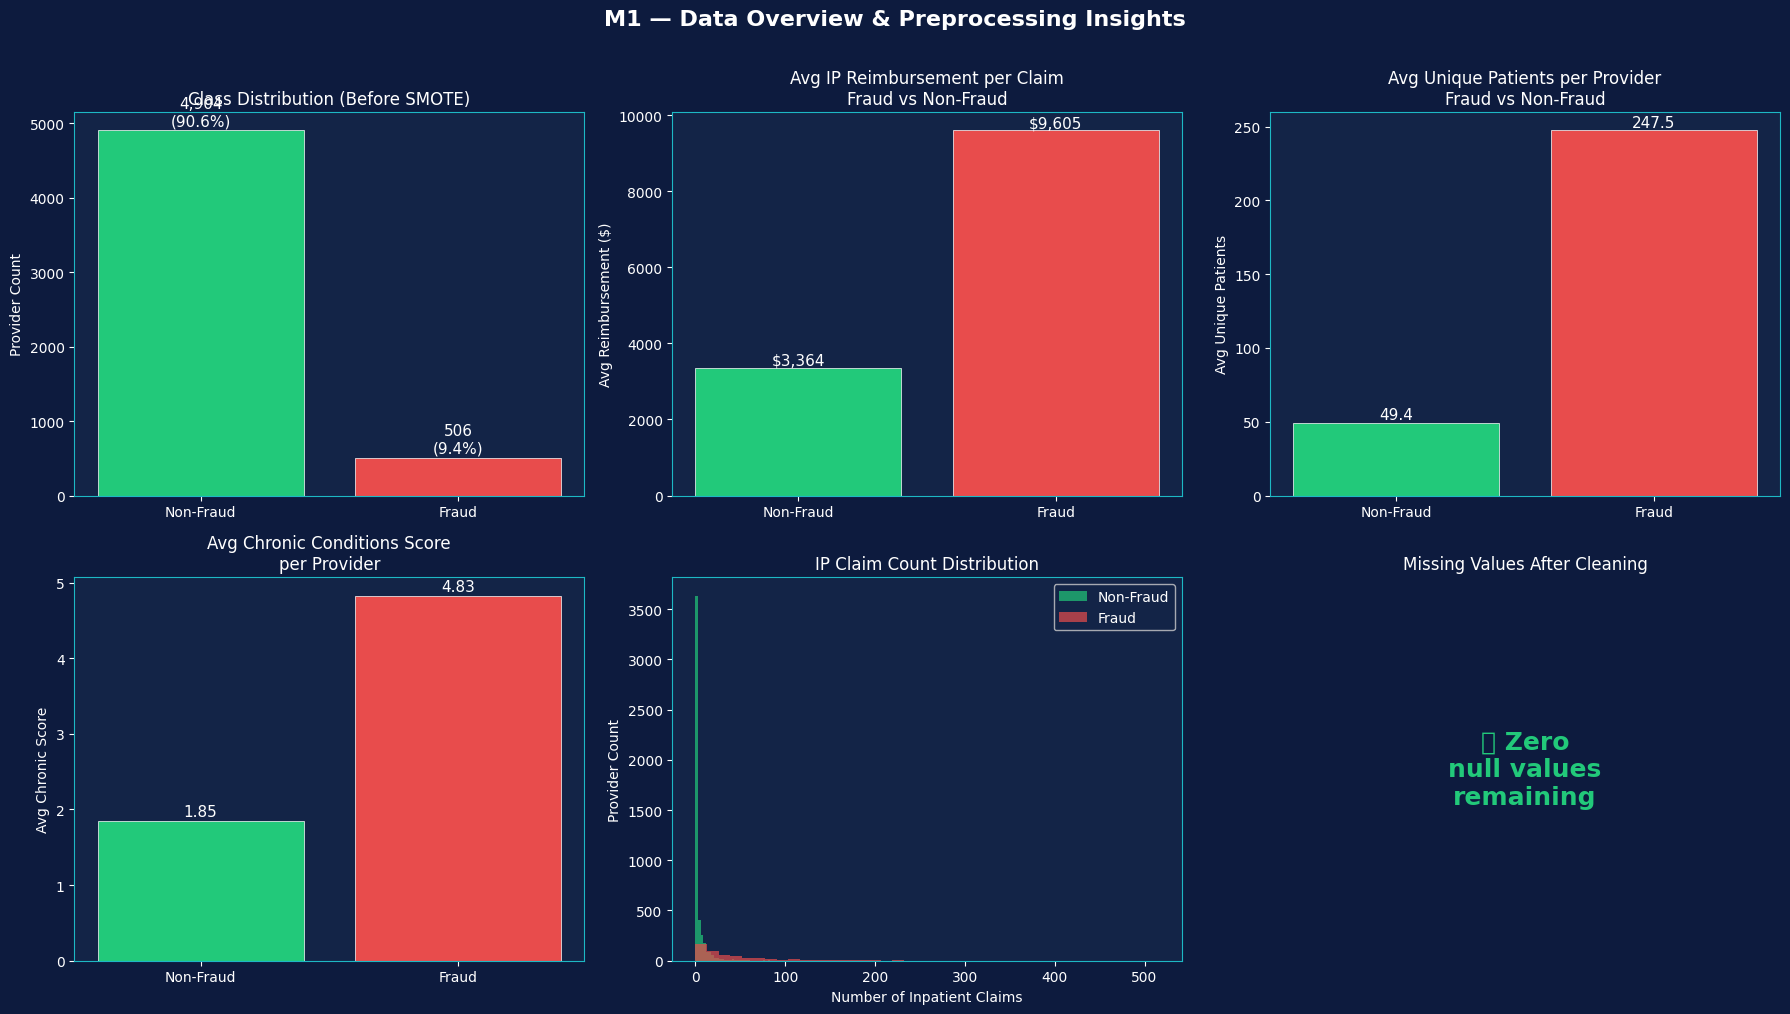


💾 Plot saved to: /content/drive/MyDrive/insurance_fraud/processed/M1_preprocessing_overview.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('M1 — Data Overview & Preprocessing Insights', fontsize=16, color='white', fontweight='bold', y=1.01)

# ── Plot 1: Class Distribution ─────────────────────────────────────────────────
ax = axes[0, 0]
counts = train_final['fraud_label'].value_counts()
bars = ax.bar(['Non-Fraud', 'Fraud'], counts.values,
              color=[GREEN, RED], edgecolor='white', linewidth=0.5)
ax.set_title('Class Distribution (Before SMOTE)', color='white')
ax.set_ylabel('Provider Count')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(train_final)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, color='white')

# ── Plot 2: Avg Reimbursement by Fraud Label ───────────────────────────────────
ax = axes[0, 1]
reimb_by_fraud = train_final.groupby('fraud_label')['ip_avg_reimbursement'].mean()
bars = ax.bar(['Non-Fraud', 'Fraud'], reimb_by_fraud.values,
              color=[GREEN, RED], edgecolor='white', linewidth=0.5)
ax.set_title('Avg IP Reimbursement per Claim\nFraud vs Non-Fraud', color='white')
ax.set_ylabel('Avg Reimbursement ($)')
for bar, val in zip(bars, reimb_by_fraud.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=11, color='white')

# ── Plot 3: Avg Unique Patients per Provider ───────────────────────────────────
ax = axes[0, 2]
patients_by_fraud = train_final.groupby('fraud_label')['total_unique_patients'].mean()
bars = ax.bar(['Non-Fraud', 'Fraud'], patients_by_fraud.values,
              color=[GREEN, RED], edgecolor='white', linewidth=0.5)
ax.set_title('Avg Unique Patients per Provider\nFraud vs Non-Fraud', color='white')
ax.set_ylabel('Avg Unique Patients')
for bar, val in zip(bars, patients_by_fraud.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=11, color='white')

# ── Plot 4: Avg Chronic Conditions ─────────────────────────────────────────────
ax = axes[1, 0]
chronic_by_fraud = train_final.groupby('fraud_label')['ip_avg_chronic_cond'].mean()
bars = ax.bar(['Non-Fraud', 'Fraud'], chronic_by_fraud.values,
              color=[GREEN, RED], edgecolor='white', linewidth=0.5)
ax.set_title('Avg Chronic Conditions Score\nper Provider', color='white')
ax.set_ylabel('Avg Chronic Score')
for bar, val in zip(bars, chronic_by_fraud.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, color='white')

# ── Plot 5: IP Claim Count Distribution ───────────────────────────────────────
ax = axes[1, 1]
ax.hist(train_final[train_final['fraud_label']==0]['ip_claim_count'],
        bins=40, color=GREEN, alpha=0.7, label='Non-Fraud', edgecolor='none')
ax.hist(train_final[train_final['fraud_label']==1]['ip_claim_count'],
        bins=40, color=RED, alpha=0.7, label='Fraud', edgecolor='none')
ax.set_title('IP Claim Count Distribution', color='white')
ax.set_xlabel('Number of Inpatient Claims')
ax.set_ylabel('Provider Count')
ax.legend()

# ── Plot 6: Null heatmap ───────────────────────────────────────────────────────
ax = axes[1, 2]
null_pct = (train_final.isnull().mean() * 100)
null_pct = null_pct[null_pct > 0]
if len(null_pct) > 0:
    null_pct.sort_values(ascending=True).plot(kind='barh', ax=ax, color=ACCENT)
    ax.set_title('Remaining Null % by Feature', color='white')
    ax.set_xlabel('% Missing')
else:
    ax.text(0.5, 0.5, '✅ Zero\nnull values\nremaining',
            ha='center', va='center', fontsize=18, color=GREEN,
            transform=ax.transAxes, fontweight='bold')
    ax.set_title('Missing Values After Cleaning', color='white')
    ax.axis('off')

plt.tight_layout()
plot_path = OUTPUT_DIR + 'M1_preprocessing_overview.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight', facecolor='#0D1B3E')
plt.show()
print(f'\n💾 Plot saved to: {plot_path}')

## Cell 13 — Apply SMOTE to Balance Classes

Before SMOTE — Class distribution:
  Counter({0: 4904, 1: 506})
  Fraud ratio: 9.4%

After SMOTE — Class distribution:
  Counter({0: 4904, 1: 4904})
  Fraud ratio: 50.0%

  Original train size : 5,410
  SMOTE train size    : 9,808


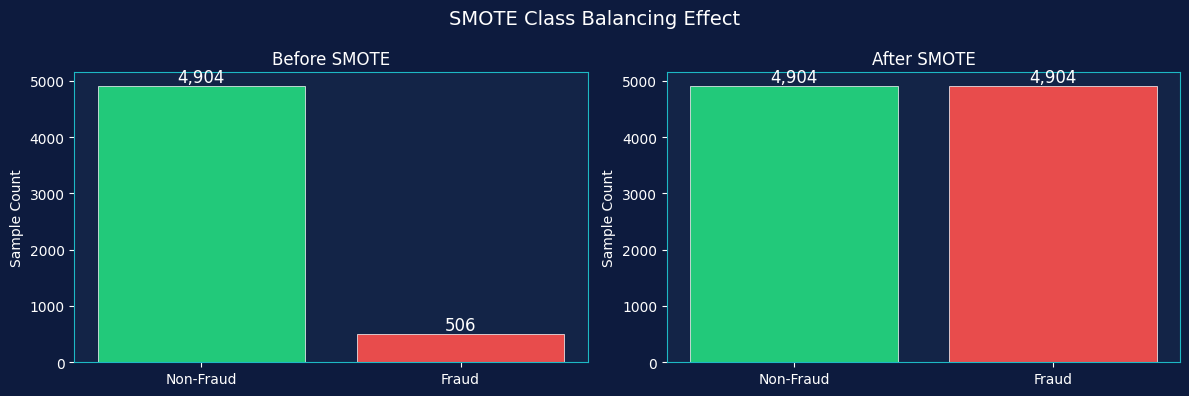


💾 SMOTE plot saved to: /content/drive/MyDrive/insurance_fraud/processed/M1_smote_balancing.png


In [ ]:
# Separate features and target
# Only use labeled rows for training
feature_cols = [c for c in train_final.columns if c not in ['Provider', 'fraud_label']]

X_train = train_final[feature_cols].copy()
y_train = train_final['fraud_label'].copy()

# Test set — drop placeholder label column, use for inference only
X_test = test_final[feature_cols].copy()
y_test = None  # No labels available for test set
X_train = train_final[feature_cols].copy()
y_train = train_final['fraud_label'].copy()
X_test  = test_final[feature_cols].copy()
y_test  = test_final['fraud_label'].copy()

# Ensure all features are numeric (SMOTE requires this)
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test  = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f'Before SMOTE — Class distribution:')
print(f'  {Counter(y_train)}')
print(f'  Fraud ratio: {y_train.mean()*100:.1f}%')

# Apply SMOTE — creates synthetic minority (fraud) samples
# random_state ensures reproducibility
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'\nAfter SMOTE — Class distribution:')
print(f'  {Counter(y_train_sm)}')
print(f'  Fraud ratio: {y_train_sm.mean()*100:.1f}%')
print(f'\n  Original train size : {len(X_train):,}')
print(f'  SMOTE train size    : {len(X_train_sm):,}')

# Visualise SMOTE effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('SMOTE Class Balancing Effect', fontsize=14, color='white')

for ax, (counts_dict, title) in zip(axes, [
    (Counter(y_train), 'Before SMOTE'),
    (Counter(y_train_sm), 'After SMOTE'),
]):
    bars = ax.bar(['Non-Fraud', 'Fraud'],
                  [counts_dict[0], counts_dict[1]],
                  color=[GREEN, RED], edgecolor='white', linewidth=0.5)
    ax.set_title(title, color='white')
    ax.set_ylabel('Sample Count')
    for bar, val in zip(bars, [counts_dict[0], counts_dict[1]]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val:,}', ha='center', va='bottom', fontsize=12, color='white')

plt.tight_layout()
smote_plot_path = OUTPUT_DIR + 'M1_smote_balancing.png'
plt.savefig(smote_plot_path, dpi=150, bbox_inches='tight', facecolor='#0D1B3E')
plt.show()
print(f'\n💾 SMOTE plot saved to: {smote_plot_path}')

## Cell 14 — Final Summary & Feature List

In [ ]:
print('='*65)
print('  M1 PREPROCESSING SUMMARY')
print('='*65)
print(f'  Train providers (raw)     : {len(train_labels):,}')
print(f'  Train providers (merged)  : {len(train_final):,}')
print(f'  Test  providers (merged)  : {len(test_final):,}')
print(f'  Total features            : {len(feature_cols)}')
print(f'  Train samples after SMOTE : {len(X_train_sm):,}')
print(f'  SMOTE fraud ratio         : {y_train_sm.mean()*100:.1f}%')
print(f'  Remaining null values     : {X_train_sm.isnull().sum().sum()}')
print('='*65)
print(f'\n  📊 Features created ({len(feature_cols)} total):')
for i, col in enumerate(feature_cols, 1):
    print(f'    {i:02d}. {col}')

  M1 PREPROCESSING SUMMARY
  Train providers (raw)     : 5,410
  Train providers (merged)  : 5,410
  Test  providers (merged)  : 1,353
  Total features            : 32
  Train samples after SMOTE : 9,808
  SMOTE fraud ratio         : 50.0%
  Remaining null values     : 0

  📊 Features created (32 total):
    01. ip_claim_count
    02. ip_unique_patients
    03. ip_total_reimbursement
    04. ip_avg_reimbursement
    05. ip_max_reimbursement
    06. ip_total_deductible
    07. ip_avg_deductible
    08. ip_avg_stay_days
    09. ip_max_stay_days
    10. ip_total_stay_days
    11. ip_avg_patient_age
    12. ip_deceased_patient_count
    13. ip_avg_chronic_cond
    14. ip_max_chronic_cond
    15. ip_unique_attending_phys
    16. ip_unique_operating_phys
    17. ip_avg_annual_ip_reimb
    18. ip_avg_annual_op_reimb
    19. op_claim_count
    20. op_unique_patients
    21. op_total_reimbursement
    22. op_avg_reimbursement
    23. op_max_reimbursement
    24. op_total_deductible
    25. op_a

## Cell 15 — Save All Outputs to Google Drive

In [ ]:
import pyarrow

print('💾 Saving outputs to Google Drive...')

# 1. Raw merged provider-level datasets (before SMOTE) — used for EDA
train_final.to_parquet(OUTPUT_DIR + 'train_provider_merged.parquet', index=False)
test_final.to_parquet(OUTPUT_DIR + 'test_provider_merged.parquet', index=False)
print('  ✅ train_provider_merged.parquet')
print('  ✅ test_provider_merged.parquet')

# 2. SMOTE-balanced train data — used for Model Training (M4)
X_train_sm_df = pd.DataFrame(X_train_sm, columns=feature_cols)
X_train_sm_df['fraud_label'] = y_train_sm.values
X_train_sm_df.to_parquet(OUTPUT_DIR + 'train_smote_balanced.parquet', index=False)
print('  ✅ train_smote_balanced.parquet')

# 3. Test set (no SMOTE — always evaluate on real distribution)
X_test_df = pd.DataFrame(X_test, columns=feature_cols)
X_test_df['fraud_label'] = y_test.values
X_test_df.to_parquet(OUTPUT_DIR + 'test_final.parquet', index=False)
print('  ✅ test_final.parquet')

# 4. Feature column list — so other notebooks know what features were created
import json
with open(OUTPUT_DIR + 'feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)
print('  ✅ feature_columns.json')

print(f'\n🎉 All files saved to: {OUTPUT_DIR}')


💾 Saving outputs to Google Drive...
  ✅ train_provider_merged.parquet
  ✅ test_provider_merged.parquet
  ✅ train_smote_balanced.parquet
  ✅ test_final.parquet
  ✅ feature_columns.json

🎉 All files saved to: /content/drive/MyDrive/insurance_fraud/processed/
